In [1]:
import pandas as pd

testing_end_date = '2024-04-01'

# Load data
train_df = pd.read_csv('~/data/Transfer learning/large data 2015/cross_border_electricity_prices_one_shot.csv')
test_df = pd.read_csv('~/data/Transfer learning/large data 2015/DE-LU_testing_data_with_calendar.csv')

# # Filter train_df to include only data from 2020 onward
test_df = test_df[pd.to_datetime(test_df['ds']) <= pd.Timestamp(testing_end_date)]

# Convert to UTC while handling DST ambiguities
train_df['ds'] = pd.to_datetime(train_df['ds']).dt.tz_localize('Europe/Berlin', ambiguous='infer').dt.tz_convert('UTC')
test_df['ds'] = pd.to_datetime(test_df['ds']).dt.tz_localize('Europe/Berlin', ambiguous='infer').dt.tz_convert('UTC')

# Check date ranges
print("First date in train_df:", train_df['ds'].min())
print("Last date in train_df:", train_df['ds'].max())
print("First date in test_df:", test_df['ds'].min())
print("Last date in test_df:", test_df['ds'].max())


calendar_features = ['month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos', 
                     'hour_sin', 'hour_cos', 'is_holiday', 'is_weekend']


# Define the exogenous variable lists
stat_exog_list = [] 
hist_exog_list = (
    calendar_features
)

futr_exog_list = (
    calendar_features
)


First date in train_df: 2015-01-01 00:00:00+00:00
Last date in train_df: 2023-12-31 22:00:00+00:00
First date in test_df: 2023-12-31 23:00:00+00:00
Last date in test_df: 2024-03-31 22:00:00+00:00


In [2]:
train_df.head()

,ds,y,unique_id,day_of_week,month,hour,is_weekend,is_holiday,month_sin,month_cos,day_of_week_sin,day_of_week_cos,hour_sin,hour_cos
0,2018-09-30 22:00:00+00:00,59.53,AT,0,10,0,0,0,-0.866025,0.5,0.0,1.0,0.000000,1.000000
1,2018-09-30 23:00:00+00:00,56.10,AT,0,10,1,0,0,-0.866025,0.5,0.0,1.0,0.258819,0.965926
2,2018-10-01 00:00:00+00:00,51.41,AT,0,10,2,0,0,-0.866025,0.5,0.0,1.0,0.500000,0.866025
3,2018-10-01 01:00:00+00:00,47.38,AT,0,10,3,0,0,-0.866025,0.5,0.0,1.0,0.707107,0.707107
4,2018-10-01 02:00:00+00:00,47.59,AT,0,10,4,0,0,-0.866025,0.5,0.0,1.0,0.866025,0.500000


In [3]:
train_df.tail()

,ds,y,unique_id,day_of_week,month,hour,is_weekend,is_holiday,month_sin,month_cos,day_of_week_sin,day_of_week_cos,hour_sin,hour_cos
1065668,2023-12-31 18:00:00+00:00,9.00,DE-LU,6,12,19,1,0,-2.449294e-16,1.0,-0.781831,0.62349,-0.965926,0.258819
1065669,2023-12-31 19:00:00+00:00,7.95,DE-LU,6,12,20,1,0,-2.449294e-16,1.0,-0.781831,0.62349,-0.866025,0.500000
1065670,2023-12-31 20:00:00+00:00,6.00,DE-LU,6,12,21,1,0,-2.449294e-16,1.0,-0.781831,0.62349,-0.707107,0.707107
1065671,2023-12-31 21:00:00+00:00,10.68,DE-LU,6,12,22,1,0,-2.449294e-16,1.0,-0.781831,0.62349,-0.500000,0.866025
1065672,2023-12-31 22:00:00+00:00,2.44,DE-LU,6,12,23,1,0,-2.449294e-16,1.0,-0.781831,0.62349,-0.258819,0.965926


In [4]:
test_df.head()

,ds,y,unique_id,day_of_week,month,hour,is_weekend,is_holiday,month_sin,month_cos,day_of_week_sin,day_of_week_cos,hour_sin,hour_cos
0,2023-12-31 23:00:00+00:00,0.10,DE-LU,0,1,0,0,1,0.5,0.866025,0.0,1.0,0.000000,1.000000
1,2024-01-01 00:00:00+00:00,0.01,DE-LU,0,1,1,0,1,0.5,0.866025,0.0,1.0,0.258819,0.965926
2,2024-01-01 01:00:00+00:00,0.00,DE-LU,0,1,2,0,1,0.5,0.866025,0.0,1.0,0.500000,0.866025
3,2024-01-01 02:00:00+00:00,-0.01,DE-LU,0,1,3,0,1,0.5,0.866025,0.0,1.0,0.707107,0.707107
4,2024-01-01 03:00:00+00:00,-0.03,DE-LU,0,1,4,0,1,0.5,0.866025,0.0,1.0,0.866025,0.500000


Train the Model

In [5]:
print(stat_exog_list,
      
      hist_exog_list,
      
      futr_exog_list)

[] ['month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos', 'hour_sin', 'hour_cos', 'is_holiday', 'is_weekend'] ['month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos', 'hour_sin', 'hour_cos', 'is_holiday', 'is_weekend']


In [6]:
import json

# Load the best params from the JSON file
with open("best_config_synthetic_and_co2.json", "r") as f:
    best_params = json.load(f)

best_params

{'stat_exog_list': [],
 'hist_exog_list': ['month_sin',
  'month_cos',
  'day_of_week_sin',
  'day_of_week_cos',
  'hour_sin',
  'hour_cos',
  'is_holiday',
  'is_weekend',
  'gas_price',
  'synthetic_price',
  'co2_emission_allowances'],
 'futr_exog_list': ['month_sin',
  'month_cos',
  'day_of_week_sin',
  'day_of_week_cos',
  'hour_sin',
  'hour_cos',
  'is_holiday',
  'is_weekend'],
 'input_size': 168,
 'max_steps': 500,
 'step_size': 1,
 'batch_size': 64,
 'learning_rate': 0.0002825666890659265,
 'random_seed': 10,
 'scaler_type': None,
 'windows_batch_size': 128,
 'n_harmonics': 3,
 'n_polynomials': 4,
 'stack_types': ['identity', 'trend', 'seasonality'],
 'n_blocks': [2, 2, 2],
 'mlp_units': [[2048, 2048], [2048, 2048], [2048, 2048]],
 'activation': 'Softplus',
 'h': 24}

In [7]:
# Remove exogenous lists
best_params.pop("stat_exog_list", None)
best_params.pop("hist_exog_list", None)
best_params.pop("futr_exog_list", None)

best_params

{'input_size': 168,
 'max_steps': 500,
 'step_size': 1,
 'batch_size': 64,
 'learning_rate': 0.0002825666890659265,
 'random_seed': 10,
 'scaler_type': None,
 'windows_batch_size': 128,
 'n_harmonics': 3,
 'n_polynomials': 4,
 'stack_types': ['identity', 'trend', 'seasonality'],
 'n_blocks': [2, 2, 2],
 'mlp_units': [[2048, 2048], [2048, 2048], [2048, 2048]],
 'activation': 'Softplus',
 'h': 24}

In [8]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATSx

horizon = 24
historical = 24 * 7

model_name = 'NBEATSx'

# Set up the model with horizon = 24 (for day-ahead hourly forecasts)
model = NBEATSx(
    **best_params,
    stat_exog_list=stat_exog_list,
    hist_exog_list=hist_exog_list,
    futr_exog_list=futr_exog_list,
    )

# Train the model
nf = NeuralForecast(models=[model], freq='h')
nf.fit(df=train_df)

[rank: 0] Seed set to 10
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/4
Initializing distributed: GLOBAL_RANK: 1, MEMBER: 2/4
Initializing distributed: GLOBAL_RANK: 2, MEMBER: 3/4
Initializing distributed: GLOBAL_RANK: 3, MEMBER: 4/4
----------------------------------------------------------------------------------------------------
distributed_backend=nccl
All distributed processes registered. Starting with 4 processes
----------------------------------------------------------------------------------------------------

2025-03-03 12:28:37.165851: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-03 12:28:37.181018: E external/local_xla/xla/stre

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=500` reached.
/pfs/data5/home/kit/iai/fn8011/ml/lib64/python3.9/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Test the model

In [9]:
import pytz

daterange = pd.date_range(
    start=test_df['ds'].min(),
    end=test_df['ds'].max() - pd.Timedelta(hours=historical),
    freq='24H',
)

predictions = []

for d in daterange:
    day_start = d
    day_end = d + pd.Timedelta(hours=historical)

    # 2.1) Gather input data based on historical
    input_data = test_df[(test_df['ds'] >= day_start) & (test_df['ds'] < day_end)].copy()
    if input_data.empty:
        continue

    future_data = test_df[(test_df['ds'] >= day_end)]
    
    prediction = nf.predict(df=input_data, futr_df=future_data)

    # Append predictions for evaluation
    predictions.append(prediction)

# Flatten the predictions into a DataFrame
forecast_df = pd.concat(predictions, ignore_index=True)

# Ensure the results align with the test dataset
forecast_df = forecast_df[['ds', model_name]].merge(test_df[['ds', 'y']], on='ds', how='inner')
forecast_df.rename(columns={'y': 'y_actual', model_name: 'y_pred'}, inplace=True)

# Change back to CEST
forecast_df['ds'] = forecast_df['ds'].dt.tz_convert('Europe/Berlin')


/pfs/data5/home/kit/iai/fn8011/ml/lib64/python3.9/site-packages/neuralforecast/core.py:940: UserWarning: Dropped 1,992 unused rows from `futr_df`.
  warnings.warn(f"Dropped {dropped_rows:,} unused rows from `futr_df`.")
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
2025-03-03 12:29:25.201855: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-03 12:29:25.215117: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741001365.228968  428197 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already b

Predicting: |          | 0/? [00:00<?, ?it/s]

/pfs/data5/home/kit/iai/fn8011/ml/lib64/python3.9/site-packages/neuralforecast/core.py:214: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(
/pfs/data5/home/kit/iai/fn8011/ml/lib64/python3.9/site-packages/neuralforecast/core.py:940: UserWarning: Dropped 1,968 unused rows from `futr_df`.
  warnings.warn(f"Dropped {dropped_rows:,} unused rows from `futr_df`.")
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting: |          | 0/? [00:00<?, ?it/s]

/pfs/data5/home/kit/iai/fn8011/ml/lib64/python3.9/site-packages/neuralforecast/core.py:214: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(
/pfs/data5/home/kit/iai/fn8011/ml/lib64/python3.9/site-packages/neuralforecast/core.py:940: UserWarning: Dropped 1,944 unused rows from `futr_df`.
  warnings.warn(f"Dropped {dropped_rows:,} unused rows from `futr_df`.")
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


...

/pfs/data5/home/kit/iai/fn8011/ml/lib64/python3.9/site-packages/neuralforecast/core.py:214: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(
/pfs/data5/home/kit/iai/fn8011/ml/lib64/python3.9/site-packages/neuralforecast/core.py:940: UserWarning: Dropped 24 unused rows from `futr_df`.
  warnings.warn(f"Dropped {dropped_rows:,} unused rows from `futr_df`.")
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting: |          | 0/? [00:00<?, ?it/s]

/pfs/data5/home/kit/iai/fn8011/ml/lib64/python3.9/site-packages/neuralforecast/core.py:214: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting: |          | 0/? [00:00<?, ?it/s]

/pfs/data5/home/kit/iai/fn8011/ml/lib64/python3.9/site-packages/neuralforecast/core.py:214: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


Plots

In [10]:
forecast_df.head()

,ds,y_pred,y_actual
0,2024-01-08 00:00:00+01:00,79.713608,87.02
1,2024-01-08 01:00:00+01:00,75.515381,84.32
2,2024-01-08 02:00:00+01:00,74.895920,81.82
3,2024-01-08 03:00:00+01:00,71.278824,79.11
4,2024-01-08 04:00:00+01:00,72.567482,78.48


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate error metrics
mae = mean_absolute_error(forecast_df['y_actual'], forecast_df['y_pred'])
mse = mean_squared_error(forecast_df['y_actual'], forecast_df['y_pred'])
rmse = np.sqrt(mse)

# Print the results
print("Model Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Merge forecasted values with actual test data, selecting only the relevant columns
comparison_df = forecast_df[['ds', 'y_pred']].merge(test_df[['ds', 'y']], on='ds', how='inner')
comparison_df.rename(columns={'y': 'y_actual', 'y_pred': 'y_pred'}, inplace=True)

# Add a column for the day of the week (0=Monday, 1=Tuesday, ..., 6=Sunday)
comparison_df['day_of_week'] = comparison_df['ds'].dt.dayofweek

# Calculate and display MAE, MSE, and RMSE for each day of the week
metrics_by_day = {}

for day in range(7):
    # Filter data for each day of the week
    day_data = comparison_df[comparison_df['day_of_week'] == day]

    # Calculate the metrics for this day
    mae = mean_absolute_error(day_data['y_actual'], day_data['y_pred'])
    mse = mean_squared_error(day_data['y_actual'], day_data['y_pred'])
    rmse = np.sqrt(mse)

    # Store the metrics for each day
    metrics_by_day[day] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse
    }

# Optionally, you can store these results in a DataFrame for easy viewing or further analysis
metrics_df = pd.DataFrame(metrics_by_day).T
print("\nMetrics by Day of the Week:")
print(metrics_df)

Model Performance:
Mean Absolute Error (MAE): 10.61
Mean Squared Error (MSE): 222.17
Root Mean Squared Error (RMSE): 14.91

Metrics by Day of the Week:
         MAE         MSE       RMSE
0   8.001315  127.143803  11.275806
1   9.972436  176.578537  13.288286
2  10.112063  196.041388  14.001478
3  11.771082  295.055503  17.177180
4  11.458581  252.211096  15.881155
5  10.476825  249.787494  15.804667
6  12.527521  258.859829  16.089121


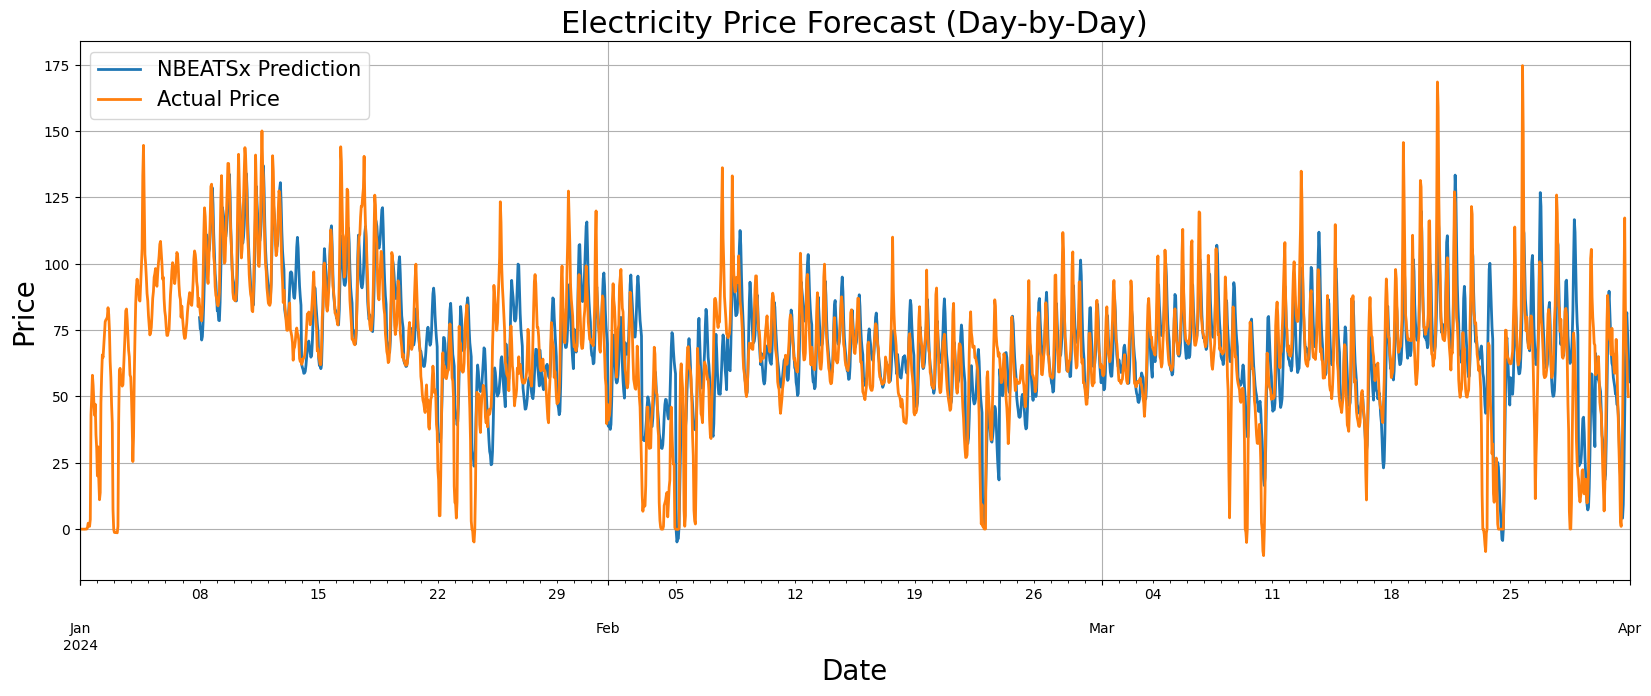

In [12]:
import matplotlib.pyplot as plt

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(20, 7))

# Plot predictions for model
forecast_df.set_index('ds')['y_pred'].plot(ax=ax, linewidth=2, label= f'{model_name} Prediction')

# Optional: Plot actual test values for comparison
test_df.set_index('ds')['y'].plot(ax=ax, linewidth=2, label='Actual Price')

# Formatting the plot
ax.set_title('Electricity Price Forecast (Day-by-Day)', fontsize=22)
ax.set_ylabel('Price', fontsize=20)
ax.set_xlabel('Date', fontsize=20)
ax.legend(prop={'size': 15})
ax.grid()
plt.show()

/scratch/slurm_tmpdir/job_25347302/ipykernel_428197/644738538.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  unique_months = forecast_df['ds'].dt.to_period('M').unique()
/scratch/slurm_tmpdir/job_25347302/ipykernel_428197/644738538.py:20: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  forecast_month = forecast_df[forecast_df['ds'].dt.to_period('M') == month]
/scratch/slurm_tmpdir/job_25347302/ipykernel_428197/644738538.py:21: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  test_month = test_df[test_df['ds'].dt.to_period('M') == month]


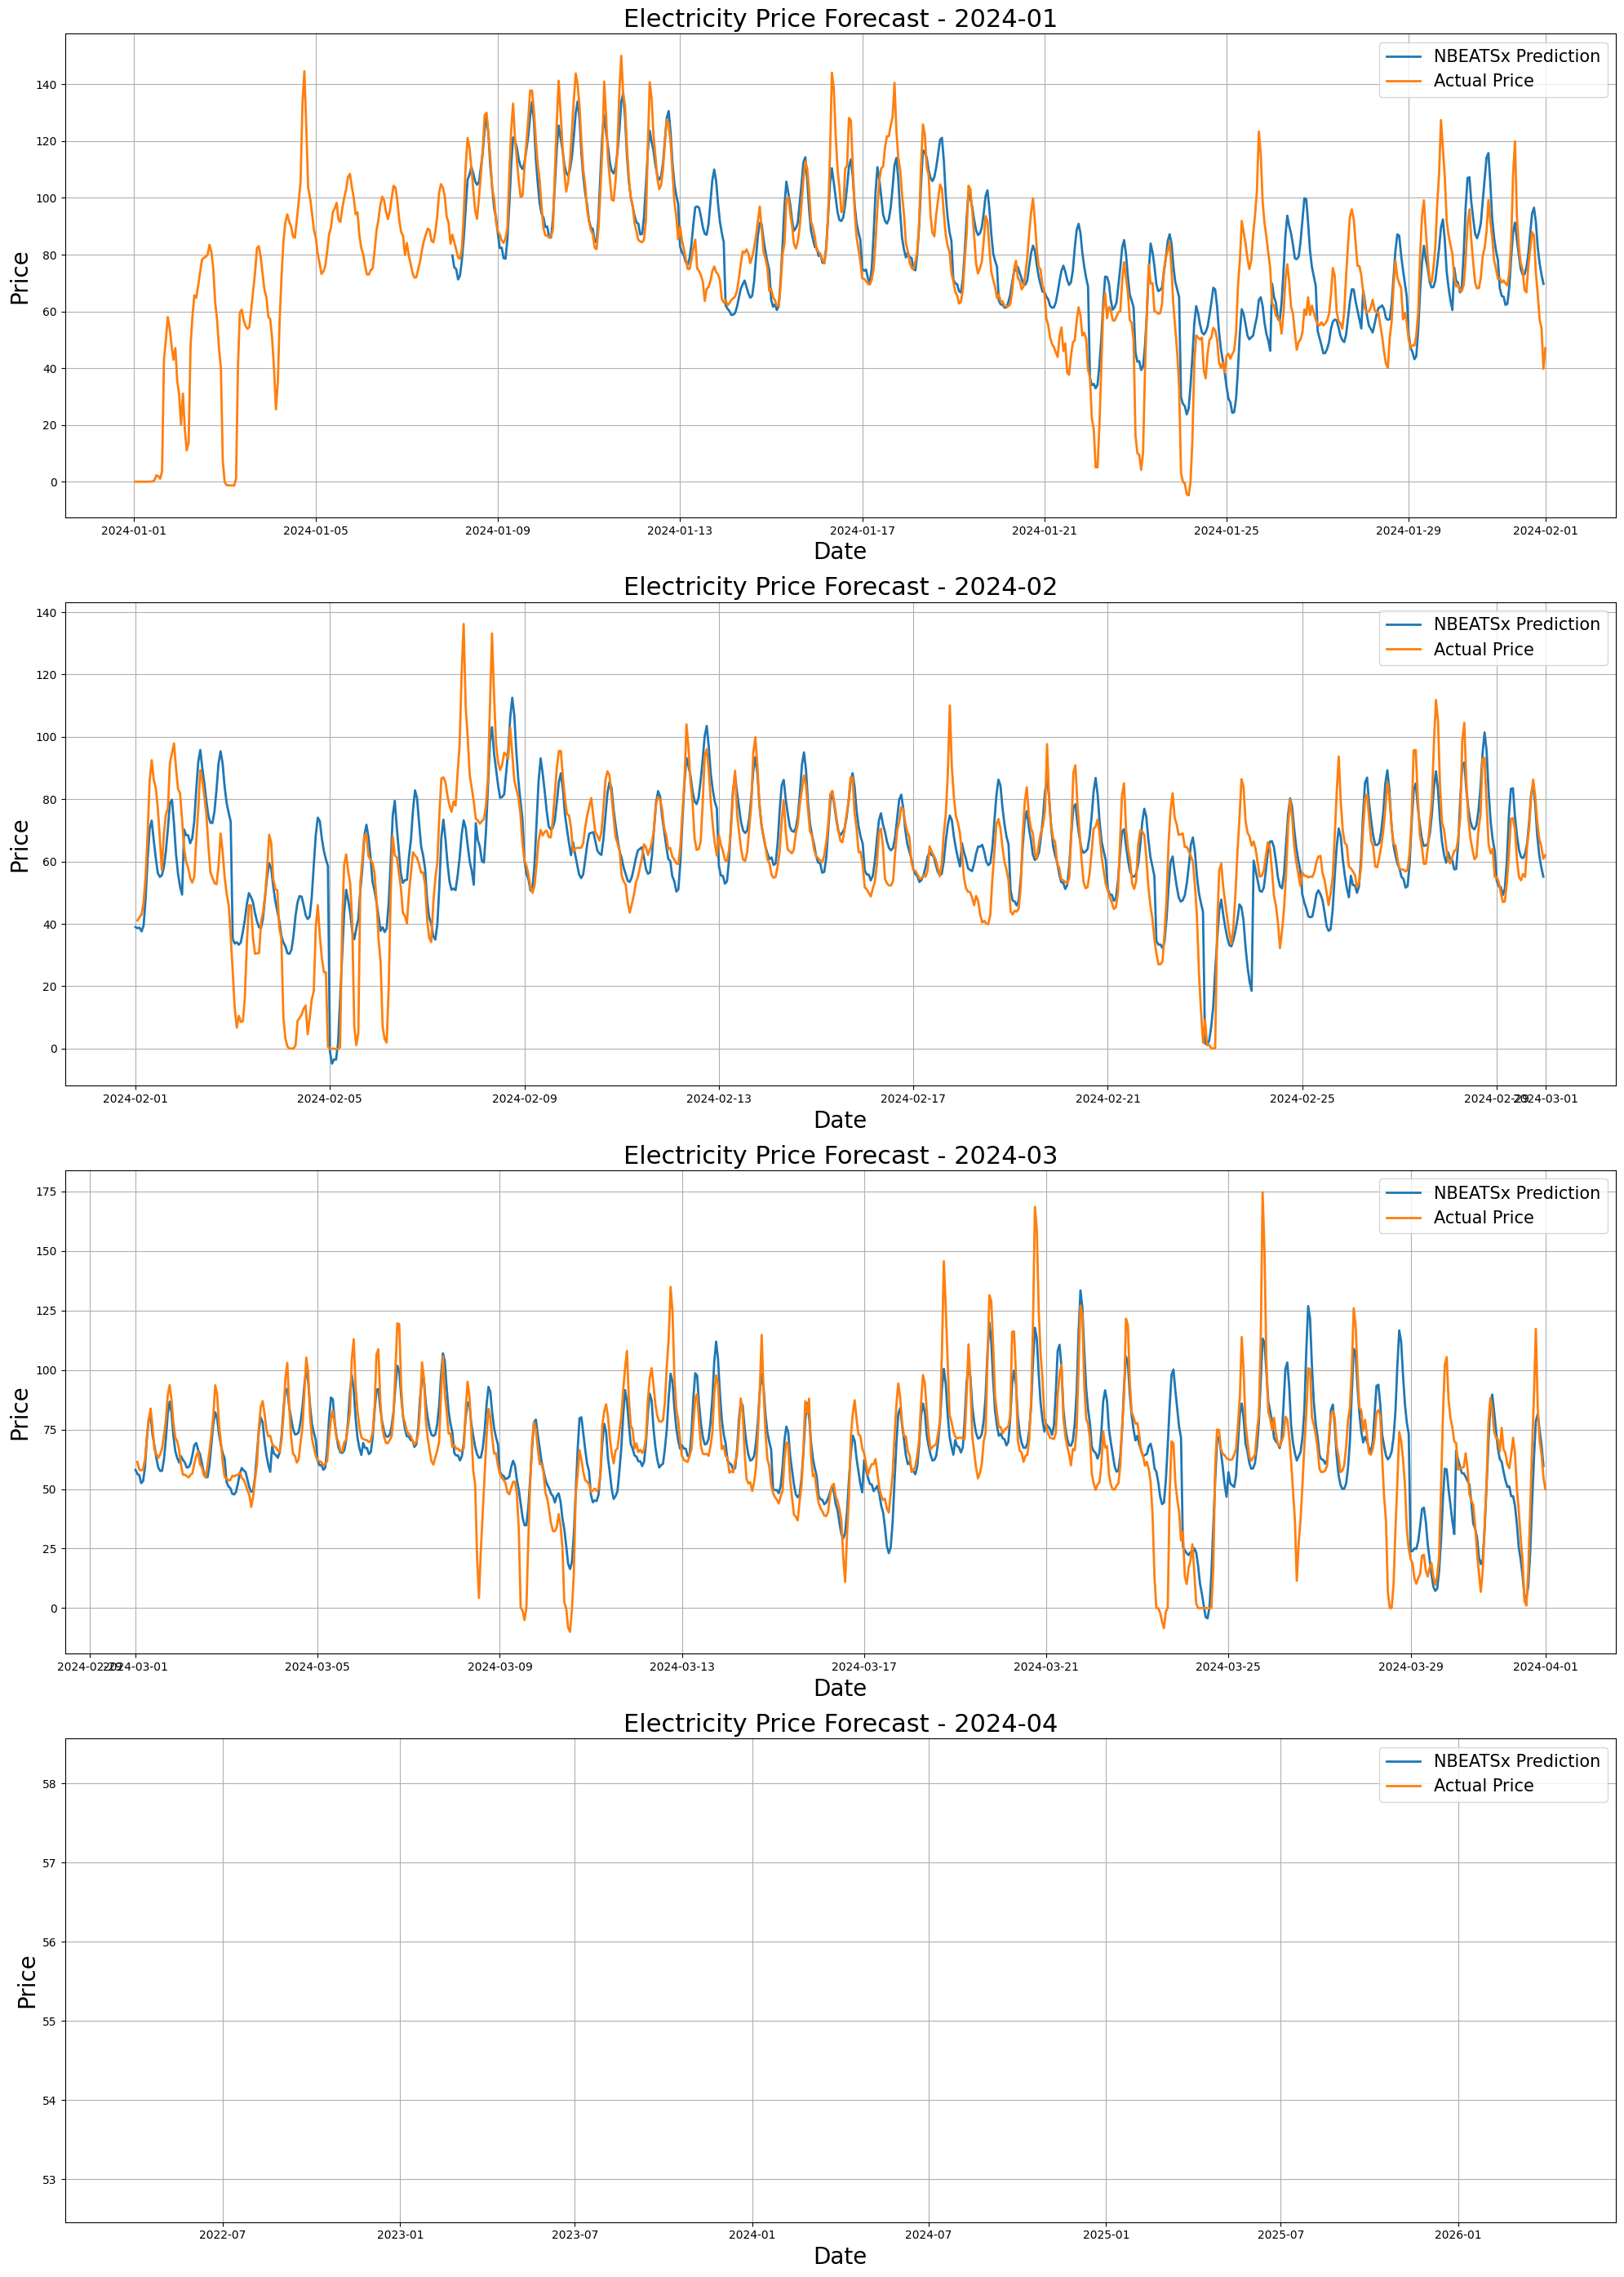

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'ds' is in datetime format
forecast_df['ds'] = pd.to_datetime(forecast_df['ds'])
test_df['ds'] = pd.to_datetime(test_df['ds'])

# Create a new figure with multiple subplots, one for each month
unique_months = forecast_df['ds'].dt.to_period('M').unique()

# Set up the figure and axes for plotting
fig, axes = plt.subplots(len(unique_months), 1, figsize=(20, 7 * len(unique_months)))

if len(unique_months) == 1:
    axes = [axes]  # Ensure axes is iterable even if there's only one subplot

for i, month in enumerate(unique_months):
    # Create the data subset for the current month
    month_str = str(month)
    forecast_month = forecast_df[forecast_df['ds'].dt.to_period('M') == month]
    test_month = test_df[test_df['ds'].dt.to_period('M') == month]

    # Plot predictions for the current month
    axes[i].plot(forecast_month['ds'], forecast_month['y_pred'], linewidth=2, label=f'{model_name} Prediction')

    # Plot actual test values for comparison in the current month
    axes[i].plot(test_month['ds'], test_month['y'], linewidth=2, label='Actual Price')

    # Formatting the plot for the current month
    axes[i].set_title(f'Electricity Price Forecast - {month_str}', fontsize=22)
    axes[i].set_ylabel('Price', fontsize=20)
    axes[i].set_xlabel('Date', fontsize=20)
    axes[i].legend(prop={'size': 15})
    axes[i].grid()

# Show the plot
plt.tight_layout()
plt.show()

/scratch/slurm_tmpdir/job_25347302/ipykernel_428197/1878128762.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  forecast_df['biweek'] = forecast_df['ds'].dt.to_period('2W')
/scratch/slurm_tmpdir/job_25347302/ipykernel_428197/1878128762.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  test_df['biweek'] = test_df['ds'].dt.to_period('2W')


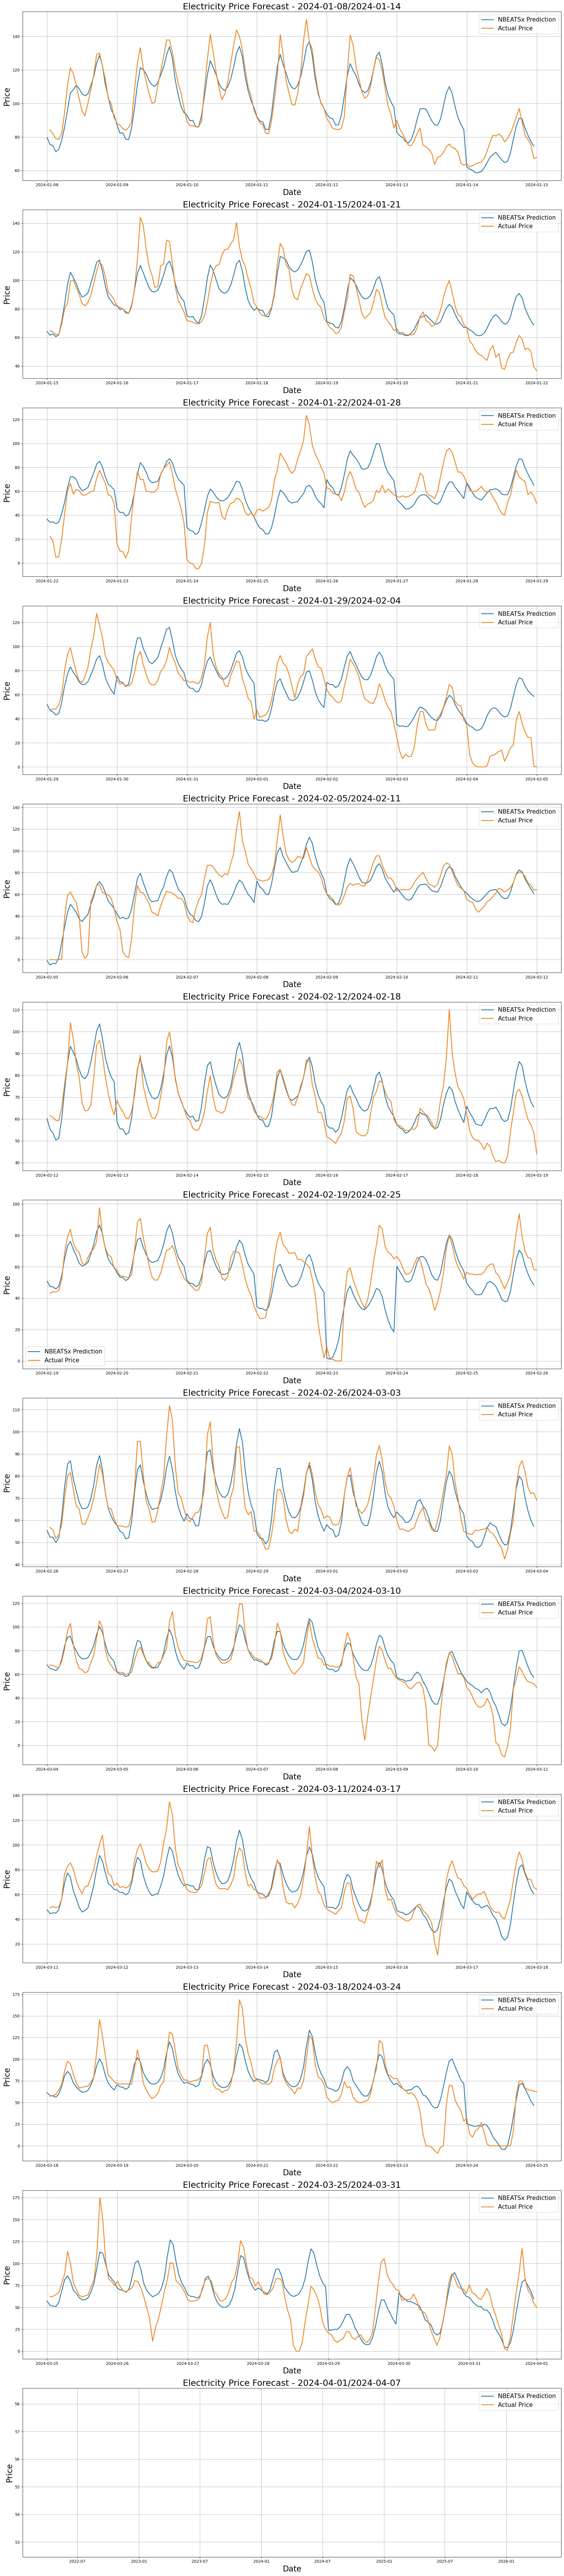

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'ds' is in datetime format
forecast_df['ds'] = pd.to_datetime(forecast_df['ds'])
test_df['ds'] = pd.to_datetime(test_df['ds'])

# Create a new figure with multiple subplots, one for each biweekly period
# Group the data by biweekly periods
forecast_df['biweek'] = forecast_df['ds'].dt.to_period('2W')
test_df['biweek'] = test_df['ds'].dt.to_period('2W')

# Get the unique biweekly periods
unique_biweeks = forecast_df['biweek'].unique()

# Set up the figure and axes for plotting
fig, axes = plt.subplots(len(unique_biweeks), 1, figsize=(20, 7 * len(unique_biweeks)))

if len(unique_biweeks) == 1:
    axes = [axes]  # Ensure axes is iterable even if there's only one subplot

for i, biweek in enumerate(unique_biweeks):
    # Create the data subset for the current biweekly period
    biweek_str = str(biweek)
    forecast_biweek = forecast_df[forecast_df['biweek'] == biweek]
    test_biweek = test_df[test_df['biweek'] == biweek]

    # Plot predictions for the current biweekly period
    axes[i].plot(forecast_biweek['ds'], forecast_biweek['y_pred'], linewidth=2, label=f'{model_name} Prediction')

    # Plot actual test values for comparison in the current biweekly period
    axes[i].plot(test_biweek['ds'], test_biweek['y'], linewidth=2, label='Actual Price')

    # Formatting the plot for the current biweekly period
    axes[i].set_title(f'Electricity Price Forecast - {biweek_str}', fontsize=22)
    axes[i].set_ylabel('Price', fontsize=20)
    axes[i].set_xlabel('Date', fontsize=20)
    axes[i].legend(prop={'size': 15})
    axes[i].grid()

# Show the plot
plt.tight_layout()
plt.show()